# Email Spam Detection and Risk Analysis System

This notebook demonstrates a rule-based spam detection pipeline.

Workflow:
1. Load dataset using pandas
2. Build EmailMessage objects
3. Compute weighted risk scores
4. Classify emails
5. Evaluate performance
6. Visualize prediction distribution

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

from src.spam_filter import SpamFilter

In [3]:
spam_filter = SpamFilter()
df = spam_filter.load_data("data/emails.csv")
df.head()

,sender,subject,body,label
0,boss@company.com,Meeting Reminder,Please attend the meeting at 2 PM today,not spam
1,winner@promo-deals.com,FREE PRIZE!!!,CLICK NOW to claim your money at http://spam.com,spam
2,friend@gmail.com,Lunch Tomorrow,Are we still on for lunch tomorrow?,not spam
3,offer@loan-winner.com,URGENT OFFER,Limited time loan approval click now!!!,spam
4,professor@stevens.edu,Assignment Update,The assignment deadline is extended by one day,not spam


In [4]:
spam_filter.build_messages()
len(spam_filter.messages), spam_filter.messages[0]

(5, <src.email_message.EmailMessage at 0x20cc0dd8830>)

In [5]:
results = spam_filter.predict_all()
results

,index,sender,actual_label,prediction,score
0,0,boss@company.com,not spam,not spam,2
1,1,winner@promo-deals.com,spam,spam,24
2,2,friend@gmail.com,not spam,not spam,0
3,3,offer@loan-winner.com,spam,suspicious,9
4,4,professor@stevens.edu,not spam,not spam,0


In [6]:
results.to_csv("data/predictions.csv", index=False)
results

,index,sender,actual_label,prediction,score
0,0,boss@company.com,not spam,not spam,2
1,1,winner@promo-deals.com,spam,spam,24
2,2,friend@gmail.com,not spam,not spam,0
3,3,offer@loan-winner.com,spam,suspicious,9
4,4,professor@stevens.edu,not spam,not spam,0


In [7]:
results["actual_binary"] = results["actual_label"].apply(
    lambda x: "spam" if x == "spam" else "not spam"
)
results["pred_binary"] = results["prediction"].apply(
    lambda x: "spam" if x == "spam" else "not spam"
)

accuracy = (results["actual_binary"] == results["pred_binary"]).mean()
accuracy

np.float64(0.8)

## Model Evaluation

We compute overall classification accuracy by comparing predicted labels with actual labels.

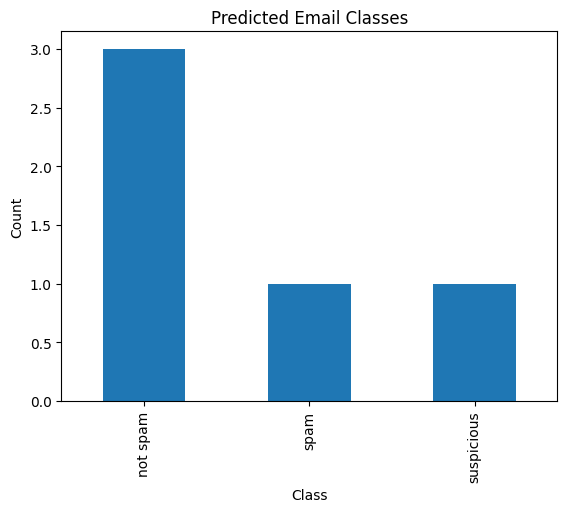

In [8]:
results["prediction"].value_counts().plot(kind="bar")
plt.title("Predicted Email Classes")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()